In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import numpy as np

df = pd.read_csv(r'..\results\essemble_prediction_table.csv')

df = df.rename(columns={
    'embedding_attention_mlp': 'Embedding_Attention_MLP',
    'lightGBM': 'LightGBM',
    'deep_residual_mlp': 'Deep_Residual_MLP'
})

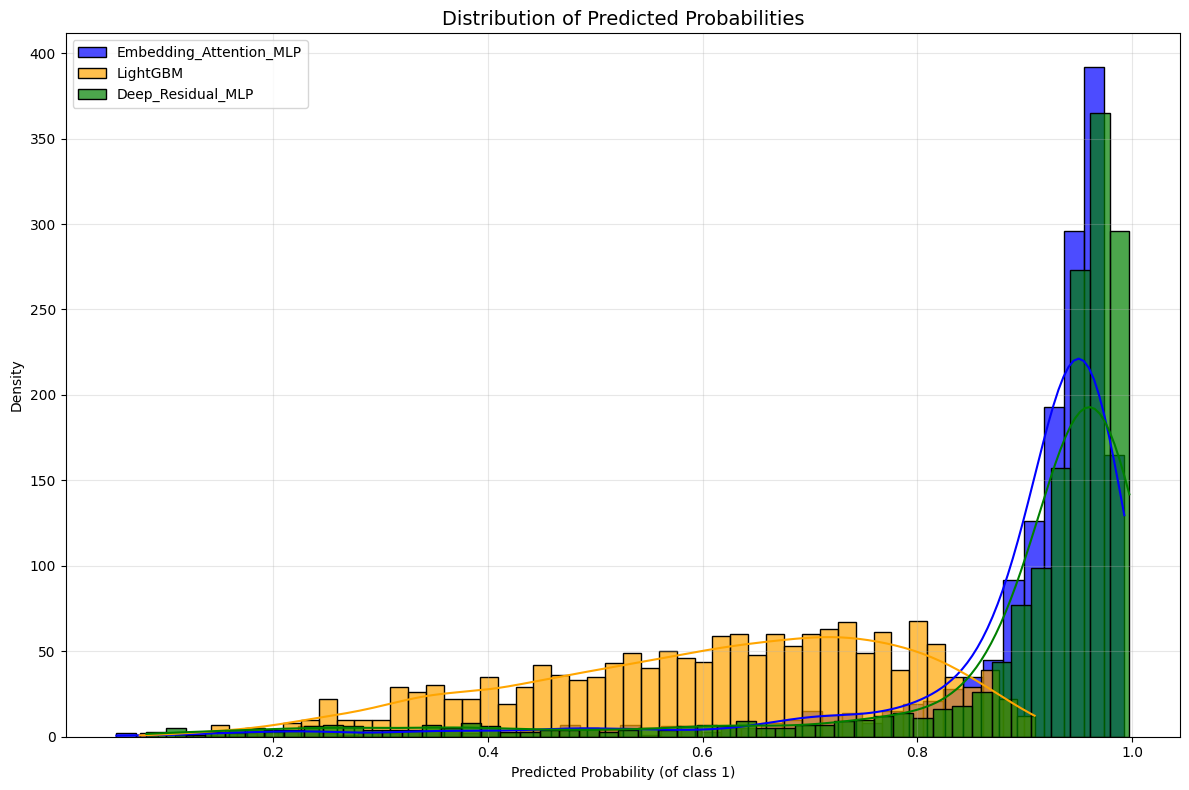

In [8]:

# ====================== 1. Distribution of Predicted Probabilities ======================
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='Embedding_Attention_MLP', kde=True, color='blue', label='Embedding_Attention_MLP', alpha=0.7, bins=50)
sns.histplot(data=df, x='LightGBM', kde=True, color='orange', label='LightGBM', alpha=0.7, bins=50)
sns.histplot(data=df, x='Deep_Residual_MLP', kde=True, color='green', label='Deep_Residual_MLP', alpha=0.7, bins=50)

plt.title('Distribution of Predicted Probabilities', fontsize=14)
plt.xlabel('Predicted Probability (of class 1)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


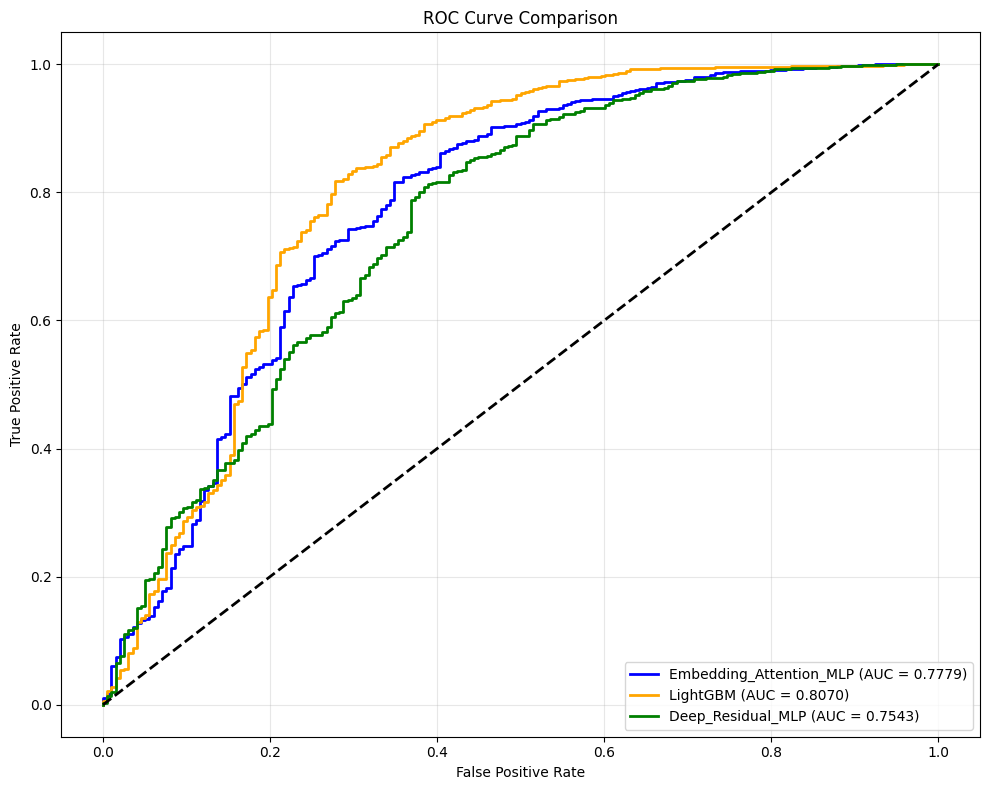

In [9]:
# ====================== 2. ROC Curve ======================
plt.figure(figsize=(10, 8))

for model, color in zip(['Embedding_Attention_MLP', 'LightGBM', 'Deep_Residual_MLP'], ['blue', 'orange', 'green']):
    fpr, tpr, _ = roc_curve(df['Actual'], df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{model} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


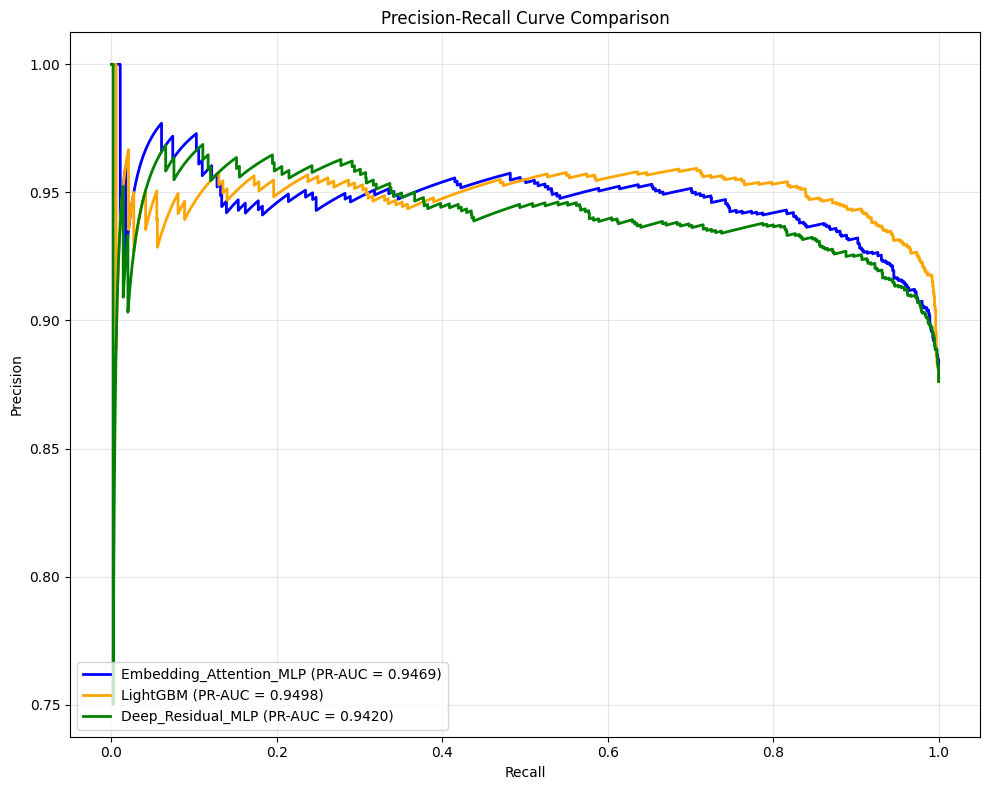

In [10]:
# ====================== 3. Precision-Recall Curve ======================
plt.figure(figsize=(10, 8))

for model, color in zip(['Embedding_Attention_MLP', 'LightGBM', 'Deep_Residual_MLP'], ['blue', 'orange', 'green']):
    precision, recall, _ = precision_recall_curve(df['Actual'], df[model])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color, lw=2, label=f'{model} (PR-AUC = {pr_auc:.4f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

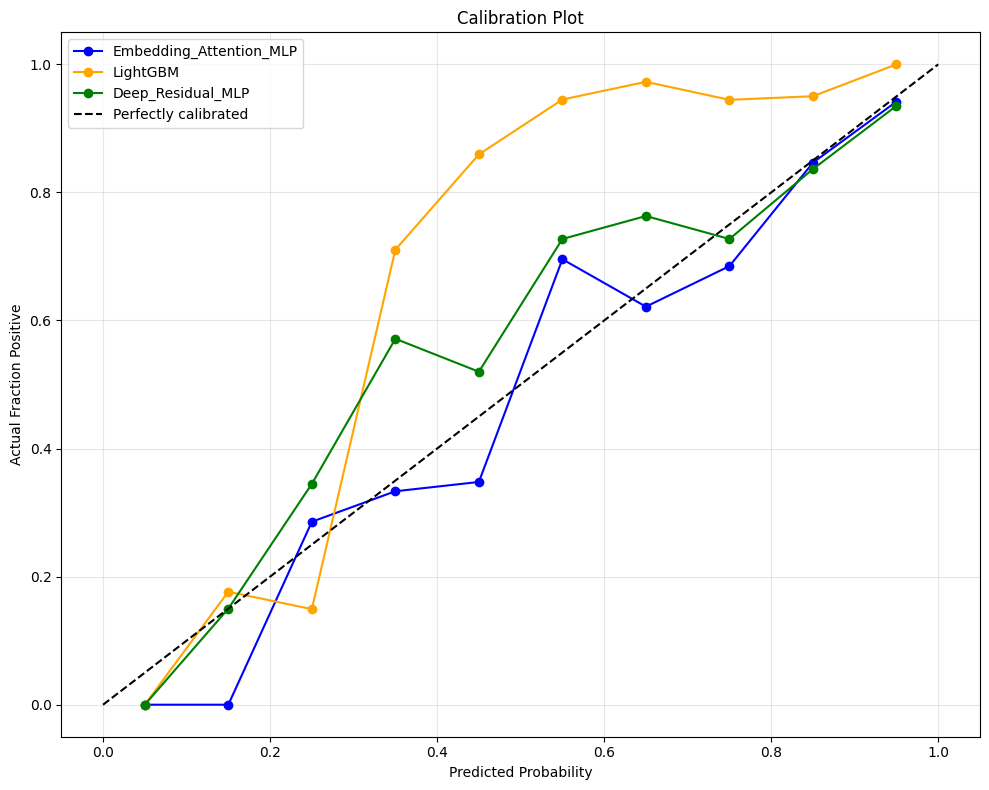

In [ ]:

# ====================== 4. Calibration Plot ======================
plt.figure(figsize=(10, 8))

n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)

for model, color, marker in zip(
    ['Embedding_Attention_MLP', 'LightGBM', 'Deep_Residual_MLP'],
    ['blue', 'orange', 'green'],
    ['o', 'o', 'o']
):
    probs = df[model].values
    actual = df['Actual'].values
    
    bin_centers = []
    fractions = []
    
    for i in range(n_bins):
        left = bin_edges[i]
        right = bin_edges[i+1]
        mask = (probs >= left) & (probs < right)
        if mask.sum() > 0:
            bin_centers.append((left + right) / 2)
            fractions.append(actual[mask].mean())
    
    plt.plot(bin_centers, fractions, 'o-', color=color, label=model, markersize=6)

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

plt.title('Calibration Plot')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Fraction Positive')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

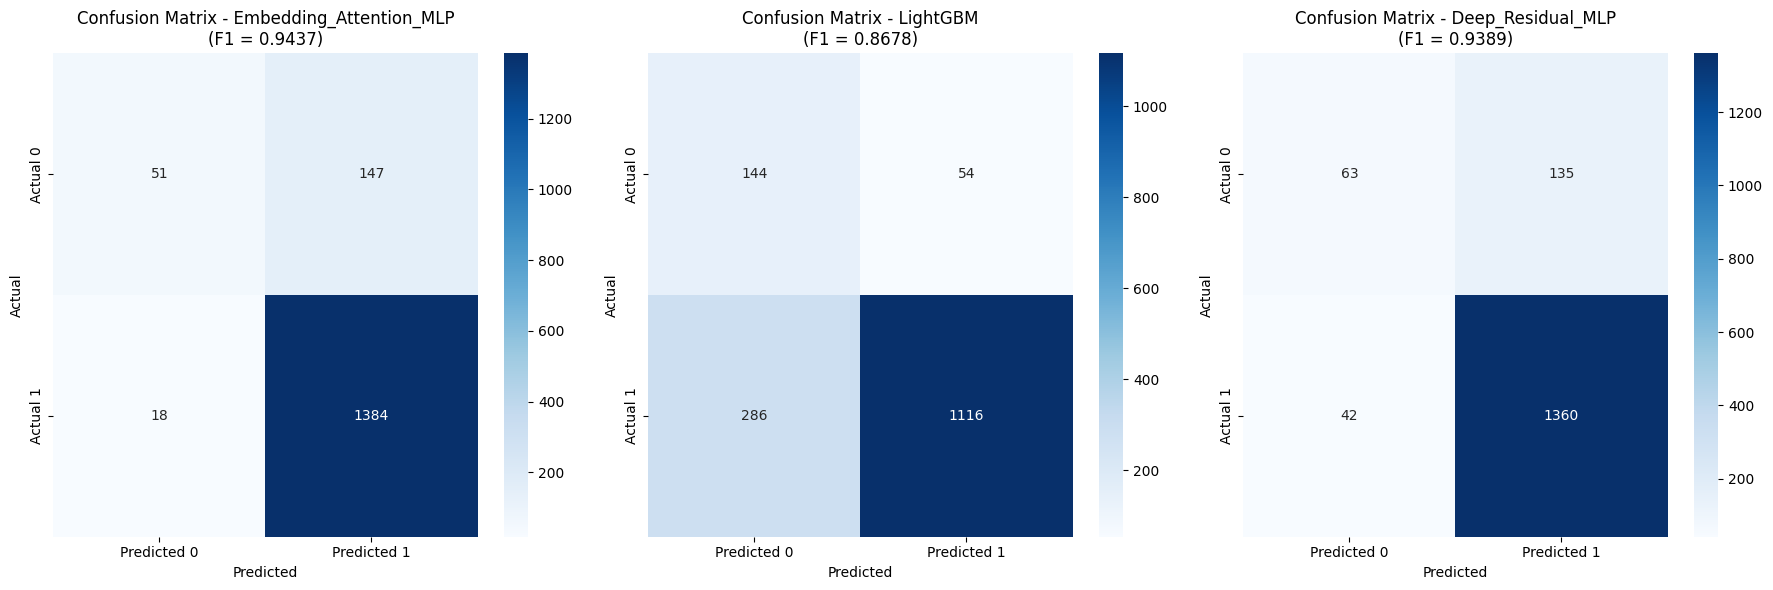

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Embedding_Attention_MLP', 'LightGBM', 'Deep_Residual_MLP']
titles = ['Embedding_Attention_MLP', 'LightGBM', 'Deep_Residual_MLP']

for ax, model, title in zip(axes, models, titles):
    # Threshold = 0.5
    y_pred = (df[model] >= 0.5).astype(int)
    cm = confusion_matrix(df['Actual'], y_pred)
    f1 = f1_score(df['Actual'], y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True)
    ax.set_title(f'Confusion Matrix - {title}\n(F1 = {f1:.4f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
    ax.set_yticklabels(['Actual 0', 'Actual 1'])

plt.tight_layout()
plt.show()